# Validation Metrics

This section evaluates the model using traditional classification metrics.

We report:
- Validation loss
- Top-1 accuracy
- Top-3 accuracy
- Top-5 accuracy

These metrics provide a baseline comparison with previous supervised learning approaches.

In [76]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

import sqlite3

import json

import gzip

import pandas as pd

In [3]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import Tensorizer

from src.data.dataset import MahjongDataset

from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

from src.training.metrics import (
    compute_topk_accuracy,
)

from src.utils.tile_decoder import (
    tile136_to_string,
)

from src.utils.action_decoder import (
    decode_action,
)

from src.analysis.ukeire import (
    evaluate_discards_ukeire,
)

from src.analysis.error_analysis import (
    categorize_mistake,
)

In [4]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

In [5]:
val_dataset = MahjongDataset(

    db_path="../data/discard/strategic.db",

    limit=100000,
)

print(len(val_dataset))

100000


In [6]:
val_loader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collator.collate,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True,
)

In [7]:
model = MahjongTransformer()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
checkpoint = torch.load(

    "../checkpoints/strategic_100k/strategic_baseline.pt",

    map_location=device,
)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [10]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [11]:
model.to(device)

model.eval()

print("Checkpoint loaded.")

Checkpoint loaded.


In [12]:
criterion = torch.nn.CrossEntropyLoss()

total_loss = 0

total_correct = 0

total_samples = 0

In [13]:
with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        batch_loss = 0

        for logits, target in zip(
            logits_list,
            targets,
        ):

            target = target.unsqueeze(0)

            logits = logits.unsqueeze(0)

            loss = criterion(
                logits,
                target,
            )

            batch_loss += loss.item()

            prediction = torch.argmax(
                logits,
                dim=1,
            )

            total_correct += (
                prediction == target
            ).sum().item()

            total_samples += 1

        total_loss += batch_loss

  0%|          | 0/1563 [00:00<?, ?it/s]/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 1563/1563 [02:35<00:00, 10.05it/s]


In [14]:
val_loss = total_loss / len(val_loader)

val_accuracy = total_correct / total_samples

print(f"Validation Loss: {val_loss:.4f}")

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 64.0993
Validation Accuracy: 0.6675


In [15]:
top3_correct = 0

top3_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top3_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=3,
        )

        top3_total += len(targets)

top3 = top3_correct / top3_total

print(f"Top-3 Accuracy: {top3:.4f}")

  0%|          | 0/1563 [00:00<?, ?it/s]

100%|██████████| 1563/1563 [02:31<00:00, 10.34it/s]

Top-3 Accuracy: 0.0141


In [16]:
top5_correct = 0

top5_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top5_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=5,
        )

        top5_total += len(targets)

top5 = top5_correct / top5_total

print(f"Top-5 Accuracy: {top5:.4f}")

100%|██████████| 1563/1563 [02:29<00:00, 10.47it/s]

Top-5 Accuracy: 0.0149


# Strategic Evaluation

Exact action matching is insufficient for Mahjong because multiple discards can produce equivalent strategic outcomes.

To address this, we evaluate:
- Shanten preservation
- Effective ukeire
- Strategic mistake categories

In [17]:
conn = sqlite3.connect(
    "../data/discard/strategic.db"
)

In [123]:
results = []

In [124]:
NUM_SAMPLES = 1000

In [125]:
for offset in tqdm(range(NUM_SAMPLES)):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(row[0])
    )

    row_result["offset"] = offset

    canonical_state = {

    "round_wind":
        decoded["round_wind"],

    "num_honba":
        decoded["num_honba"],

    "num_riichi":
        decoded["num_riichi"],

    "player_wind":
        decoded["player_wind"],

    "position":
        decoded["position"],

    "remain_tiles":
        decoded["remain_tiles"],

    "dora_indicators":
        decoded["dora_indicators"],

    "hand_tiles":
        decoded["hand_tiles"],

    "players": {

        "0": decoded["0"],
        "1": decoded["1"],
        "2": decoded["2"],
        "3": decoded["3"],
    },

    "valid_actions":
        decoded["valid_actions"],

    "action_idx":
        decoded["action_idx"],
    }

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch = collator.collate(
        [tensor_dict]
    )

    batch = {

        k: v.to(device)
        if isinstance(v, torch.Tensor)
        else v

        for k, v in batch.items()
    }

    with torch.no_grad():

        logits = model(batch)[0]

    probabilities = torch.softmax(
        logits,
        dim=0,
    )

    prediction = torch.argmax(
        probabilities
    ).item()

    expert_action = decoded[
        "valid_actions"
    ][
        decoded["action_idx"]
    ]

    model_action = decoded[
        "valid_actions"
    ][prediction]

    if expert_action["type"] != 1:
        continue

    if model_action["type"] != 1:
        continue

    expert_tile = expert_action[
        "tiles"
    ][0]

    model_tile = model_action[
        "tiles"
    ][0]

    discard_eval = evaluate_discards_ukeire(
        canonical_state
    )

    discard_lookup = {}

    for r in discard_eval:

        discard_lookup[
            r["discard"]
        ] = r

    expert_metrics = discard_lookup[
        expert_tile
    ]

    model_metrics = discard_lookup[
        model_tile
    ]

    row_result = {

    "expert_tile":
        tile136_to_string(
            expert_tile
        ),

    "model_tile":
        tile136_to_string(
            model_tile
        ),

    "same_action":
        expert_tile == model_tile,

    "expert_shanten":
        expert_metrics["shanten"],

    "model_shanten":
        model_metrics["shanten"],

    "expert_ukeire":
        expert_metrics["ukeire"],

    "model_ukeire":
        model_metrics["ukeire"],

    "shanten_difference":
        (
            expert_metrics["shanten"]
            -
            model_metrics["shanten"]
        ),

    "ukeire_difference":
        (
            expert_metrics["ukeire"]
            -
            model_metrics["ukeire"]
        ),

    "model_prob":
        probabilities[
            prediction
        ].item(),
    }

    row_result["category"] = (
        categorize_mistake(
            row_result
        )
    )

    results.append(
        row_result
    )

100%|██████████| 1000/1000 [00:11<00:00, 84.01it/s]


In [130]:
results_df = pd.DataFrame(
    results
)

results_df.head()

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
0,east,west,False,4,4,66,67,0,-1,0.534196,near_equivalent,1.0
1,red,west,False,4,4,71,72,0,-1,0.534368,near_equivalent,2.0
2,west,west,True,3,3,32,32,0,0,0.460348,exact_match,3.0
3,south,south,True,3,3,52,52,0,0,0.677493,exact_match,4.0
4,2m,2m,True,3,3,54,54,0,0,0.652961,exact_match,5.0


In [131]:
results_df.groupby("category").size()

category
better_shanten      29
better_ukeire       44
equivalent         120
exact_match        657
near_equivalent     65
shanten_loss        32
ukeire_loss         53
dtype: int64

In [132]:
results_df.groupby("category")[

    [
        "shanten_difference",
        "ukeire_difference",
    ]

].mean()

,shanten_difference,ukeire_difference
category,,
better_shanten,1.0,26.034483
better_ukeire,0.0,-10.477273
equivalent,0.0,0.000000
exact_match,0.0,0.000000
near_equivalent,0.0,0.092308
shanten_loss,-1.0,-18.250000
ukeire_loss,0.0,7.000000


In [133]:
summary = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",
        "Strategic Accuracy",
        "Mean Ukeire Difference",
    ],

    "Value": [

        results_df["same_action"].mean(),

        results_df["category"].isin([
            "exact_match",
            "equivalent",
            "near_equivalent",
        ]).mean(),

        results_df["ukeire_difference"].mean(),
    ]
})

summary

,Metric,Value
0,Exact Accuracy,0.657
1,Strategic Accuracy,0.842
2,Mean Ukeire Difference,0.087


In [134]:
distribution = (

    results_df["category"]

    .value_counts(normalize=True)
)

distribution

category
exact_match        0.657
equivalent         0.120
near_equivalent    0.065
ukeire_loss        0.053
better_ukeire      0.044
shanten_loss       0.032
better_shanten     0.029
Name: proportion, dtype: float64

In [135]:
results_df[
    "ukeire_difference"
].mean()

np.float64(0.087)

In [136]:
results_df[
    "same_action"
].mean()

np.float64(0.657)

In [137]:
worst = results_df[

    results_df["category"].isin([
        "catastrophic",
        "shanten_loss",
        "ukeire_loss",
    ])
]

worst = worst.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        False,
    ],
)

worst.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
54,8m,red,False,0,1,3,3,-1,0,0.315576,shanten_loss,55.0
868,6m,6p,False,0,1,3,3,-1,0,0.388298,shanten_loss,869.0
255,6m,6s,False,0,1,6,7,-1,-1,0.428052,shanten_loss,256.0
919,2p,7p,False,1,2,6,8,-1,-2,0.203412,shanten_loss,920.0
923,8p,8s,False,1,2,8,11,-1,-3,0.158413,shanten_loss,924.0
858,2s,6p,False,1,2,19,23,-1,-4,0.226508,shanten_loss,859.0
156,7s,9m,False,1,2,11,16,-1,-5,0.270846,shanten_loss,157.0
601,2p,3s,False,1,2,11,16,-1,-5,0.264707,shanten_loss,602.0
878,1p,2s,False,0,1,5,10,-1,-5,0.317848,shanten_loss,879.0
187,5m,2p,False,1,2,16,22,-1,-6,0.156304,shanten_loss,188.0


In [138]:
best = results_df[

    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
        "near_equivalent",
        "equivalent",
    ])
]

best = best.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        True,
    ],
)

best.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
227,6p,1s,False,2,1,12,12,1,0,0.769425,better_shanten,228.0
716,north,south,False,1,0,8,4,1,4,0.660505,better_shanten,717.0
281,3s,9m,False,4,3,50,43,1,7,0.386359,better_shanten,282.0
548,green,3m,False,1,0,10,3,1,7,0.587116,better_shanten,549.0
788,south,2s,False,3,2,71,62,1,9,0.392499,better_shanten,789.0
789,south,2s,False,4,3,70,61,1,9,0.508333,better_shanten,790.0
280,7m,red,False,3,2,28,15,1,13,0.413132,better_shanten,281.0
933,8p,white,False,3,2,52,35,1,17,0.482985,better_shanten,934.0
289,8p,9m,False,3,2,33,15,1,18,0.720306,better_shanten,290.0
809,1s,west,False,2,1,25,6,1,19,0.691287,better_shanten,810.0


In [139]:
model_better = results_df[
    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
    ])
]

model_better.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
39,1p,8s,False,2,1,35,12,1,23,0.615280,better_shanten,40.0
80,7m,1s,False,3,3,23,42,0,-19,0.922128,better_ukeire,81.0
95,green,2p,False,3,2,60,25,1,35,0.547336,better_shanten,96.0
99,5s,north,False,3,3,53,69,0,-16,0.631739,better_ukeire,100.0
105,9m,north,False,3,3,64,72,0,-8,0.776517,better_ukeire,106.0
161,3m,1m,False,1,1,17,24,0,-7,0.466593,better_ukeire,162.0
180,6s,3m,False,2,2,18,21,0,-3,0.206107,better_ukeire,181.0
184,9s,9m,False,1,1,6,10,0,-4,0.488732,better_ukeire,185.0
192,9m,south,False,2,2,38,47,0,-9,0.627803,better_ukeire,193.0
193,1s,red,False,3,3,54,62,0,-8,0.524794,better_ukeire,194.0


In [140]:
high_confidence_mistakes = results_df[

    results_df["same_action"] == False
]

high_confidence_mistakes = high_confidence_mistakes.sort_values(

    by="model_prob",

    ascending=False,
)

high_confidence_mistakes.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
567,5s,9m,False,1,1,5,5,0,0,0.975558,equivalent,568.0
392,2m,2s,False,1,1,16,17,0,-1,0.940048,near_equivalent,393.0
549,green,1p,False,2,1,38,10,1,28,0.928367,better_shanten,550.0
80,7m,1s,False,3,3,23,42,0,-19,0.922128,better_ukeire,81.0
804,red,7p,False,1,1,7,7,0,0,0.918800,equivalent,805.0
819,north,6m,False,2,2,30,14,0,16,0.912093,ukeire_loss,820.0
787,5s,2s,False,2,1,49,11,1,38,0.910476,better_shanten,788.0
385,white,east,False,2,2,31,31,0,0,0.905509,equivalent,386.0
668,white,2p,False,2,2,16,19,0,-3,0.901371,better_ukeire,669.0
398,5s,1s,False,1,1,16,29,0,-13,0.896380,better_ukeire,399.0


In [141]:
results_df["category"].value_counts()

category
exact_match        657
equivalent         120
near_equivalent     65
ukeire_loss         53
better_ukeire       44
shanten_loss        32
better_shanten      29
Name: count, dtype: int64

In [142]:
results_df.to_csv(

    "../reports/strategic_validation_analysis_100k.csv",

    index=False,
)

print("Saved.")

Saved.


In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

In [144]:
sns.set_theme(style="whitegrid")

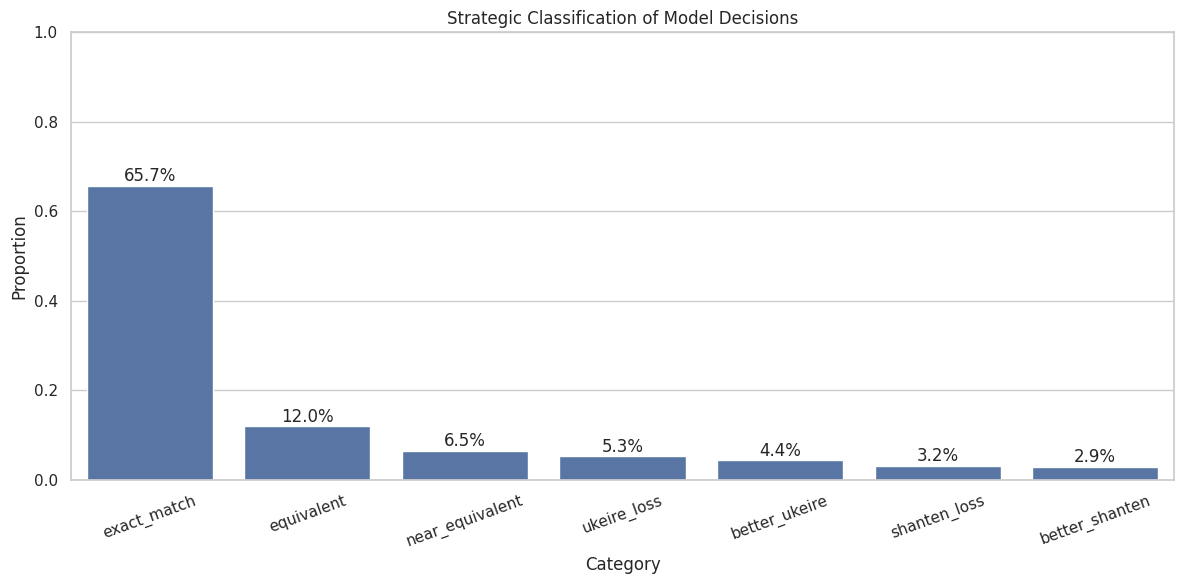

In [145]:
plt.figure(figsize=(12, 6))

sns.barplot(

    x=distribution.index,

    y=distribution.values,
)

plt.ylabel("Proportion")

plt.xlabel("Category")

plt.title(
    "Strategic Classification of Model Decisions"
)

plt.xticks(rotation=20)

plt.ylim(0, 1)

for i, value in enumerate(
    distribution.values
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )

plt.tight_layout()

plt.show()

In [146]:
plt.savefig(

    "../reports/figures/category_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [147]:
exact_accuracy = (
    results_df["same_action"]
    .mean()
)

strategic_accuracy = (

    results_df["category"]

    .isin([
        "exact_match",
        "equivalent",
        "near_equivalent",
        "better_ukeire",
        "better_shanten",
    ])

    .mean()
)

comparison_df = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",

        "Strategic Accuracy",
    ],

    "Value": [

        exact_accuracy,

        strategic_accuracy,
    ]
})

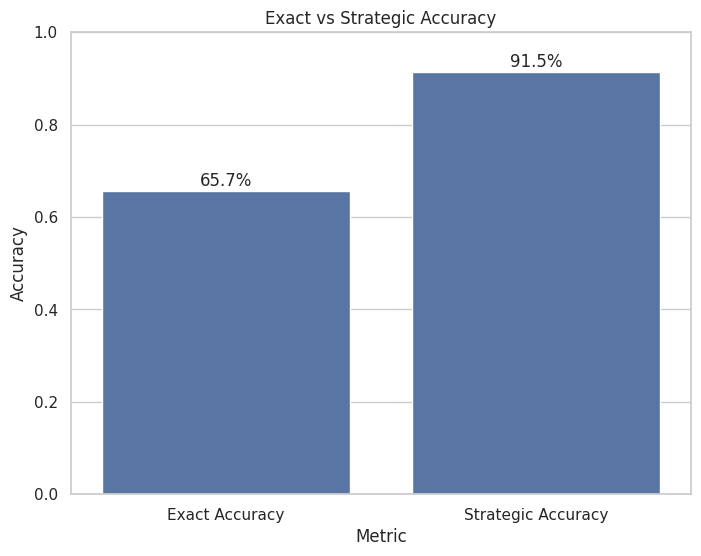

In [148]:
plt.figure(figsize=(8, 6))

sns.barplot(

    data=comparison_df,

    x="Metric",

    y="Value",
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.title(
    "Exact vs Strategic Accuracy"
)

for i, value in enumerate(
    comparison_df["Value"]
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )

plt.show()

In [149]:
plt.savefig(

    "../reports/figures/accuracy_difference_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

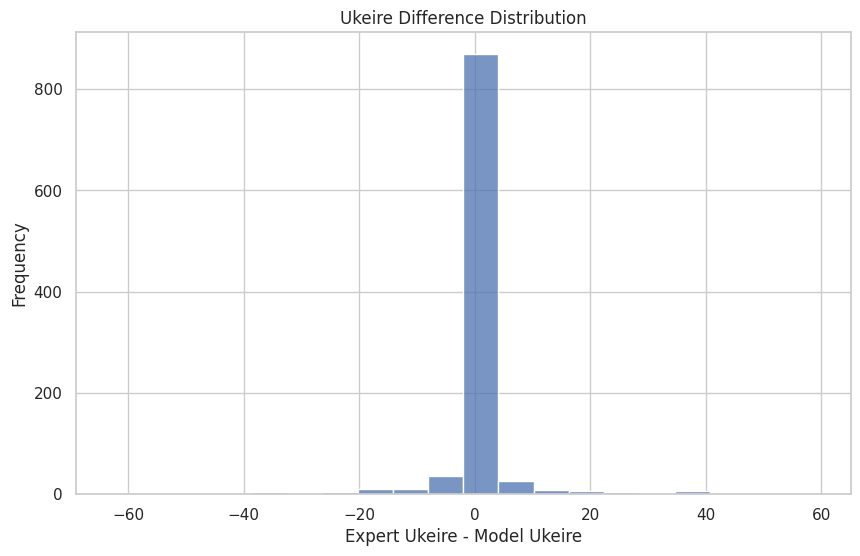

In [150]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["ukeire_difference"],

    bins=20,
)

plt.xlabel(
    "Expert Ukeire - Model Ukeire"
)

plt.ylabel("Frequency")

plt.title(
    "Ukeire Difference Distribution"
)

plt.show()

In [151]:
plt.savefig(

    "../reports/figures/ukeire_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

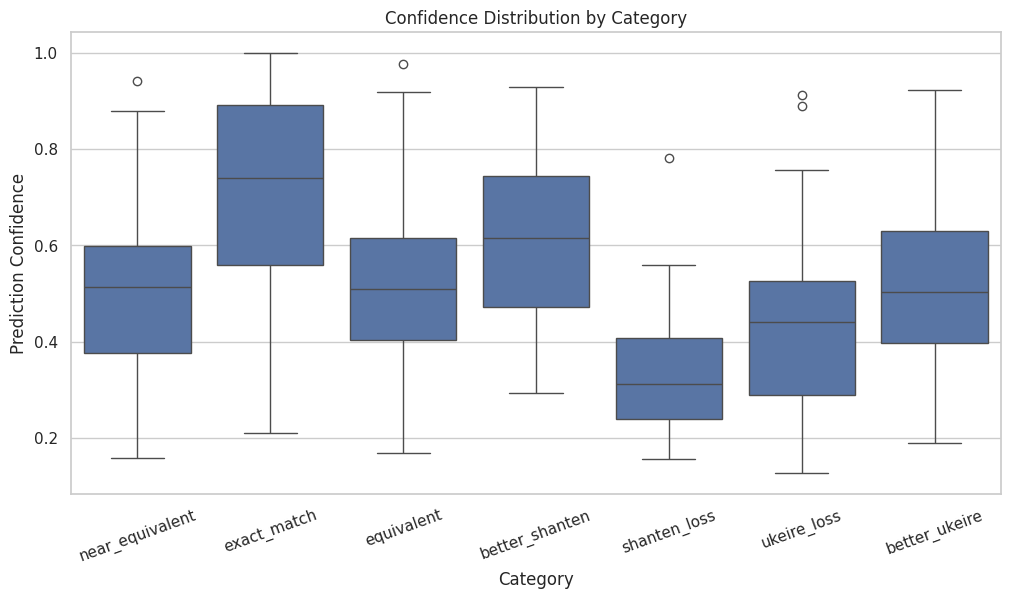

In [152]:
plt.figure(figsize=(12, 6))

sns.boxplot(

    data=results_df,

    x="category",

    y="model_prob",
)

plt.xticks(rotation=20)

plt.xlabel("Category")

plt.ylabel("Prediction Confidence")

plt.title(
    "Confidence Distribution by Category"
)

plt.show()

In [153]:
plt.savefig(

    "../reports/figures/category_confidence_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

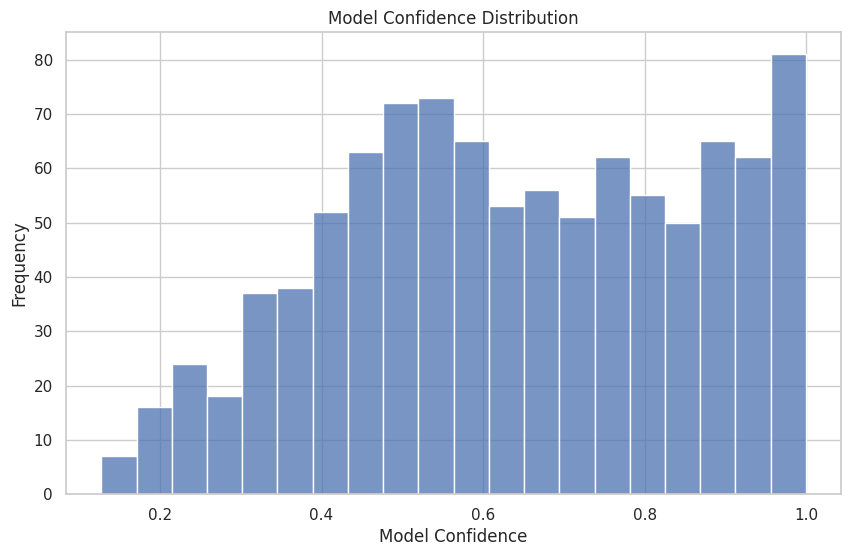

In [154]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["model_prob"],

    bins=20,
)

plt.xlabel(
    "Model Confidence"
)

plt.ylabel("Frequency")

plt.title(
    "Model Confidence Distribution"
)

plt.show()

In [155]:
plt.savefig(

    "../reports/figures/confidence_distribution_100k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

# Case Studies

Aggregate metrics provide a high-level overview of model performance, but they do not explain the nature of individual decisions.

This section presents representative examples from each strategic category:

- Exact Match
- Near Equivalent
- Better Ukeire
- Shanten Loss

For each example we inspect:

- The full Mahjong state
- The expert discard
- The model discard
- Shanten values
- Effective ukeire values

This allows qualitative analysis of the model's strategic behavior.

In [166]:
def load_state(offset):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(
            row[0]
        )
    )

    canonical_state = {

        "round_wind":
            decoded["round_wind"],

        "num_honba":
            decoded["num_honba"],

        "num_riichi":
            decoded["num_riichi"],

        "player_wind":
            decoded["player_wind"],

        "position":
            decoded["position"],

        "remain_tiles":
            decoded["remain_tiles"],

        "dora_indicators":
            decoded["dora_indicators"],

        "hand_tiles":
            decoded["hand_tiles"],

        "players": {

            "0": decoded["0"],
            "1": decoded["1"],
            "2": decoded["2"],
            "3": decoded["3"],
        },

        "valid_actions":
            decoded["valid_actions"],

        "action_idx":
            decoded["action_idx"],
    }

    return canonical_state

In [167]:
from src.utils.state_renderer import (
    render_state
)

## Case Study 1 — Exact Match

This example shows a state where the transformer selects the same discard as the expert player.

In [168]:
exact_case = results_df[

    results_df["category"]
    ==
    "exact_match"

].sample(1)

exact_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
792,9m,9m,True,2,2,44,44,0,0,0.622133,exact_match,793.0


In [176]:
state = load_state(

    int(
        exact_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 1
Riichi Sticks: 0
Remaining Tiles: 65

Dora Indicators: 8s

PLAYER 0

Points: 35700
Riichi: False

HAND:
3m 3m 4m 5m 6m 9m 2p 3p 3s 4s 5s 7s east 1m

MELDS:
None

DISCARDS:
red

PLAYER 1

Points: 18900
Riichi: False
MELDS:
None

DISCARDS:
9p

PLAYER 2

Points: 39200
Riichi: False
MELDS:
None

DISCARDS:
4s*

PLAYER 3

Points: 6200
Riichi: False
MELDS:
None

DISCARDS:
west


In [170]:
exact_case.T

,792
expert_tile,9m
model_tile,9m
same_action,True
expert_shanten,2
model_shanten,2
expert_ukeire,44
model_ukeire,44
shanten_difference,0
ukeire_difference,0
model_prob,0.622133


### Discussion

The model reproduces the expert action exactly.

This suggests that the learned policy captures the same local strategic considerations as the expert in this situation.

## Case Study 2 — Near Equivalent

This example shows a disagreement between the model and the expert.

However, the resulting hand quality remains strategically similar.

In [171]:
near_case = results_df[

    results_df["category"]
    ==
    "near_equivalent"

].sample(1)

near_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
313,5s,6p,False,2,2,14,13,0,1,0.60637,near_equivalent,314.0


In [177]:
state = load_state(

    int(
        near_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 1
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 43

Dora Indicators: 2m

PLAYER 0

Points: 23500
Riichi: False

HAND:
1m 1m 5m 7m 8m 8m 5s 7s 8s east east north north 6p

MELDS:
None

DISCARDS:
1p 1s west 8p 4p 4p* red

PLAYER 1

Points: 19200
Riichi: False
MELDS:
pon: ['red', 'red', 'red']

DISCARDS:
white 2p 9p* white* green* 7m 2s

PLAYER 2

Points: 18700
Riichi: False
MELDS:
None

DISCARDS:
9s 1m west south red 9p 1s

PLAYER 3

Points: 38600
Riichi: False
MELDS:
pon: ['south', 'south', 'south']

DISCARDS:
9s west 4m green* 5s 1m* 4s*


In [173]:
near_case.T

,313
expert_tile,5s
model_tile,6p
same_action,False
expert_shanten,2
model_shanten,2
expert_ukeire,14
model_ukeire,13
shanten_difference,0
ukeire_difference,1
model_prob,0.60637


### Discussion

The transformer chooses a different discard from the expert.

Despite this disagreement, both actions preserve hand efficiency and result in similar strategic outcomes.

## Case Study 3 — Better Ukeire

This example shows a situation where the model chooses a discard that results in a larger effective ukeire than the expert action.

In [178]:
better_case = results_df[

    results_df["category"]
    ==
    "better_ukeire"

].sort_values(

    by="ukeire_difference",

    ascending=True,
)

better_case.head(1)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
900,1s,east,False,4,4,26,73,0,-47,0.337345,better_ukeire,901.0


In [179]:
state = load_state(

    int(
        better_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 1
Honba: 2
Riichi Sticks: 0
Remaining Tiles: 61

Dora Indicators: 8s

PLAYER 0

Points: 43200
Riichi: False

HAND:
4m 7m 8m 3p 2s 4s 4s 6s 6s east white green red 1s

MELDS:
None

DISCARDS:
south 1m*

PLAYER 1

Points: 26500
Riichi: False
MELDS:
None

DISCARDS:
1p west

PLAYER 2

Points: 26200
Riichi: False
MELDS:
None

DISCARDS:
east west

PLAYER 3

Points: 4100
Riichi: False
MELDS:
None

DISCARDS:
2p west


In [180]:
better_case.head(1).T

,900
expert_tile,1s
model_tile,east
same_action,False
expert_shanten,4
model_shanten,4
expert_ukeire,26
model_ukeire,73
shanten_difference,0
ukeire_difference,-47
model_prob,0.337345


### Discussion

The model selects a discard that increases effective ukeire while preserving shanten.

This does not necessarily imply that the model found a superior Mahjong decision, since defensive considerations, hand value, and game context are not captured by the evaluation metrics.

However, it demonstrates that expert imitation and efficiency optimization are not always identical.

## Case Study 4 — Shanten Loss

This example illustrates a genuine strategic mistake.

The model chooses a discard that worsens the hand's shanten number compared to the expert action.

In [181]:
bad_case = results_df[

    results_df["category"]
    ==
    "shanten_loss"

].head(1)

bad_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
44,5s,7p,False,0,1,3,20,-1,-17,0.322717,shanten_loss,45.0


In [184]:
state = load_state(

    int(
        bad_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 3

Dora Indicators: west green

PLAYER 0

Points: 22500
Riichi: True
MELDS:
ankan: ['3s', '3s', '3s', '3s']

DISCARDS:
1p 1s red 8s 8p 5p 9s* 5s* 2p* 1s* 2p* 8m* 2s* 5m* 7s* green* 7p*

PLAYER 1

Points: 32700
Riichi: False
MELDS:
None

DISCARDS:
east red east* 8s 9s* 8s* north* south* 1p 4s 8p north* 8m 2s 2s 2s* 8p*

PLAYER 2

Points: 19800
Riichi: False

HAND:
1m 1m 3m 4m 5m 5p 7p 4s 5s 6s 5s

MELDS:
chi: ['6m', '7m', '8m']

DISCARDS:
1s 9m west* 7p 4s 7m* 4p 1s south* 9p* 9s 1p 1p 8s 5p south*

PLAYER 3

Points: 25000
Riichi: False
MELDS:
None

DISCARDS:
south west 9p east white red north 9s* 6p green* 2p 8m 2p east* 7s 7s


In [185]:
bad_case.T

,44
expert_tile,5s
model_tile,7p
same_action,False
expert_shanten,0
model_shanten,1
expert_ukeire,3
model_ukeire,20
shanten_difference,-1
ukeire_difference,-17
model_prob,0.322717


### Discussion

Unlike previous examples, the model's action directly worsens hand progression.

These cases represent true strategic failures and provide insight into the remaining weaknesses of the learned policy.

# Case Study Summary

The qualitative examples support the quantitative findings presented earlier.

Several disagreements between the model and expert players correspond to strategically equivalent alternatives rather than genuine mistakes.

Furthermore, some model decisions produce higher effective ukeire than the expert action, suggesting that exact imitation accuracy alone is insufficient to characterize Mahjong policy quality.

The most informative failures are the shanten loss cases, which represent situations where the model genuinely degrades hand efficiency.